In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import KMeans

In [33]:
df=pd.read_csv('/content/Mall_Customers.csv')

In [34]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [36]:
df['Genre']=df['Genre'].map({'Male':1,'Female':0})

In [37]:
X=df.drop('CustomerID',axis=1)

In [38]:
X

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [39]:
k_inertia=[]
k_silhouette=[]
from sklearn.metrics import silhouette_score
for i in range(3,11):
  k=KMeans(n_clusters=i)
  k.fit(X)
  k_inertia.append(k.inertia_)
  s=silhouette_score(X,k.labels_)
  k_silhouette.append(s)



In [40]:
for i in range(0,8):
  print(f"{i+3}: {k_inertia[i]} , {float(k_silhouette[i])}")

3: 154627.55913714773 , 0.3254824483854682
4: 110045.92297541516 , 0.39219951374758283
5: 82657.05476706794 , 0.37688936241822546
6: 58348.64136331505 , 0.45205475380756527
7: 51201.740785418966 , 0.4379584974420345
8: 44687.23553400544 , 0.43249096868827536
9: 44166.460127492195 , 0.38640225863240774
10: 37251.33483183482 , 0.3817975267750301


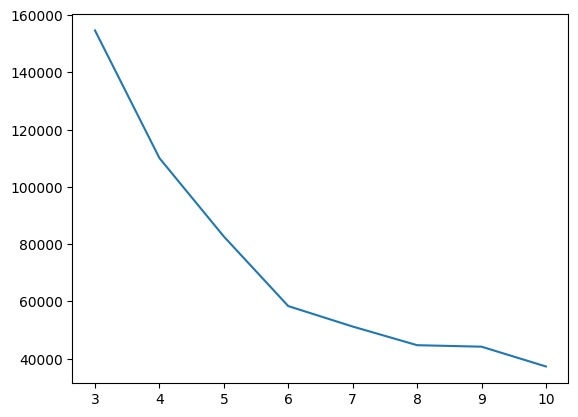

In [41]:
#ELBOW METHOd
plt.plot(range(3,11),k_inertia)
plt.show()

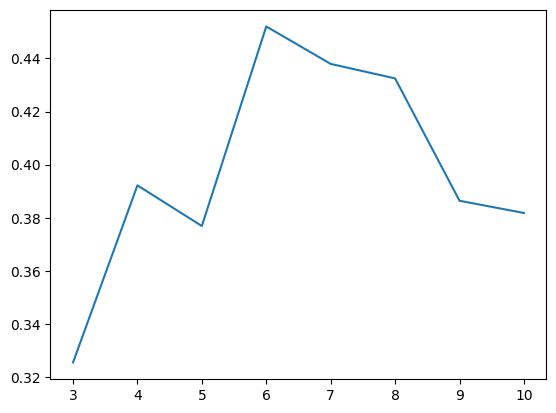

In [42]:
#Silhouette method
plt.plot(range(3,11),k_silhouette)
plt.show()

In [43]:
k_new=KMeans(n_clusters=6)
k_new.fit(X)

KMeans(n_clusters=6)

In [49]:
X['Labels']=k_new.labels_
X['Labels'].value_counts()

,count
Labels,
0,45
1,39
3,38
2,35
4,22
5,21


In [50]:
X

,Genre,Age,Annual Income (k$),Spending Score (1-100),Labels
0,1,19,15,39,5
1,1,21,15,81,4
2,0,20,16,6,5
3,0,23,16,77,4
4,0,31,17,40,5
...,...,...,...,...,...
195,0,35,120,79,1
196,0,45,126,28,2
197,1,32,126,74,1
198,1,32,137,18,2


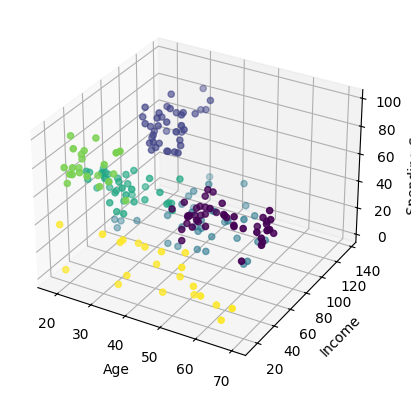

In [54]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['Age'], X['Annual Income (k$)'], df['Spending Score (1-100)'], c=k_new.labels_)

ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_zlabel('Spending Score')

plt.show()

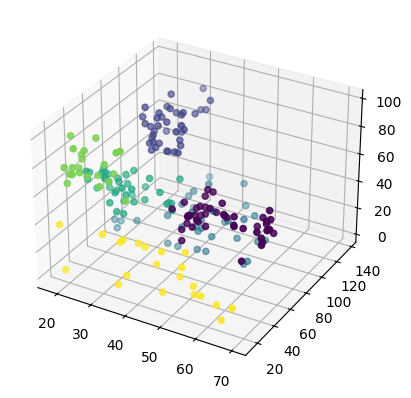

In [58]:
from mpl_toolkits.mplot3d import Axes3D
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X['Age'],X['Annual Income (k$)'],df['Spending Score (1-100)'],c=k_new.labels_)
plt.show()